In [ ]:
# libraries if running in a virtual environment
# %pip install pandas numpy scikit-learn pyarrow matplotlib tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau

def train_lstm_pipeline(dataframe, coin_symbol):
    print(f"\n" + "="*50)
    print(f"BẮT ĐẦU PIPELINE HUẤN LUYỆN CHO: {coin_symbol}")
    print("="*50)
    
    # Lấy tên viết tắt để đặt tên file sau này (Ví dụ: 'BTC/USDT' -> 'btc')
    coin_name = coin_symbol.split('/')[0].lower()
    
    # -----------------------------------------------------------------
    # BƯỚC 1: LỌC DỮ LIỆU & TÍNH BASELINE
    # -----------------------------------------------------------------
    # Lọc riêng dữ liệu theo đồng coin và sắp xếp theo thời gian 
    df_coin = dataframe[dataframe['symbol'] == coin_symbol].copy()
    df_coin = df_coin.sort_values(by='timestamp')
    
    # Chia tập Train/Test theo trình tự thời gian (Tỷ lệ 80/20) 
    train_size = int(len(df_coin) * 0.8)
    train_df = df_coin.iloc[:train_size].copy()
    test_df = df_coin.iloc[train_size:].copy()
    
    # Baseline (Naive Forecast: Dự đoán phút t+1 bằng đúng giá phút t) 
    test_df['naive_pred'] = test_df['close'].shift(1)
    test_df_baseline = test_df.dropna(subset=['naive_pred'])
    
    rmse_baseline = np.sqrt(mean_squared_error(test_df_baseline['close'], test_df_baseline['naive_pred']))
    mae_baseline = mean_absolute_error(test_df_baseline['close'], test_df_baseline['naive_pred'])
    
    # -----------------------------------------------------------------
    # BƯỚC 2 & 3: TIỀN XỬ LÝ ĐA BIẾN & CHIA TẬP KIỂM CHỨNG (VALIDATION)
    # -----------------------------------------------------------------
    # Chỉ định 2 cột 'log_returns' và 'volume' làm đặc trưng đầu vào cho mô hình LSTM
    features = ['log_returns', 'volume']
    train_data_raw = train_df[features].values
    test_data_raw = test_df[features].values
    
    # Chuẩn hóa MinMaxScaler về dải [0, 1] 
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data_raw) # Học và chuyển đổi trên tập Train
    test_scaled = scaler.transform(test_data_raw)       # Chỉ chuyển đổi trên tập Test
    
    # Hàm tạo cửa sổ trượt (Sliding Window)
    def create_sliding_window(data, window_size=60):
        X, y = [], []
        for i in range(window_size, len(data)):
            X.append(data[i-window_size:i, :])
            # Vì ta đã bỏ 'close', giờ 'log_returns' là cột đầu tiên (index 0)
            y.append(data[i, 0]) 
        return np.array(X), np.array(y)
    
    window_size = 60  
    X_train_all, y_train_all = create_sliding_window(train_scaled, window_size)
    X_test, y_test = create_sliding_window(test_scaled, window_size)
    
    # Trích xuất tiếp 20% dữ liệu cuối của tập Train làm tập Validation 
    val_size = int(len(X_train_all) * 0.2)
    X_train, y_train = X_train_all[:-val_size], y_train_all[:-val_size]
    X_val, y_val = X_train_all[-val_size:], y_train_all[-val_size:]
    
    # -----------------------------------------------------------------
    # BƯỚC 4: THIẾT KẾ KIẾN TRÚC & HUẤN LUYỆN LSTM
    # -----------------------------------------------------------------
    model = Sequential()
    
    # LSTM nhỏ gọn (units=32 là đủ)
    model.add(LSTM(units=32, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    
    # Thêm L2 penalty: Ép mô hình tiên đoán về sát 0 nếu không có tín hiệu mạnh
    model.add(Dense(units=1, kernel_regularizer=l2(1e-4)))
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
    
    # Tự động giảm tốc độ học đi một nửa (factor=0.5) nếu sau 3 vòng không tiến bộ
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr], # Thêm reduce_lr vào đây
        verbose=1
    )

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Biểu đồ Lịch sử Huấn luyện LSTM (Đã tinh chỉnh)')
    plt.xlabel('Vòng lặp (Epochs)')
    plt.ylabel('Sai số (MSE)')
    plt.legend()
    plt.show()
    
    # -----------------------------------------------------------------
    # BƯỚC 5: ĐẢO NGƯỢC CHUẨN HÓA, ĐÁNH GIÁ & XUẤT FILE
    # -----------------------------------------------------------------
    y_pred_scaled = model.predict(X_test)
    
    # Placeholder giờ CÓ 2 CỘT thay vì 3
    y_pred_placeholder = np.zeros((len(y_pred_scaled), 2))
    # log_returns hiện tại nằm ở cột index 0
    y_pred_placeholder[:, 0] = y_pred_scaled.flatten() 
    
    y_pred_actual_returns = scaler.inverse_transform(y_pred_placeholder)[:, 0]
    
    # Các bước phục hồi giá trị không thay đổi
    actual_prices = test_df['close'].values[window_size:]
    naive_prices = test_df['close'].values[window_size - 1 : -1] 
    
    y_pred_actual_close = naive_prices * np.exp(y_pred_actual_returns)
    
    rmse_baseline_fair = np.sqrt(mean_squared_error(actual_prices, naive_prices))
    rmse_lstm = np.sqrt(mean_squared_error(actual_prices, y_pred_actual_close))
    mae_lstm = mean_absolute_error(actual_prices, y_pred_actual_close)
    
    print(f"\n--- KẾT QUẢ NGHIỆM THU CHO {coin_symbol} ---")
    print(f"RMSE Baseline (Naive): {rmse_baseline_fair:.4f}")
    print(f"RMSE LSTM (Returns):   {rmse_lstm:.4f}")
    print(f"MAE LSTM:              {mae_lstm:.4f}")
    
    if rmse_lstm < rmse_baseline_fair:
        print("=> KẾT LUẬN: ĐẠT CHỈ TIÊU NGHIỆM THU.")
    else:
        print("=> KẾT LUẬN: CHƯA ĐẠT.")
        
    # Đặt tên file đầu ra động theo tham số truyền vào 
    model_filename = f"lstm_{coin_name}_model.h5"
    scaler_filename = f"scaler_{coin_name}.pkl"
    
    model.save(model_filename)
    joblib.dump(scaler, scaler_filename)
    print(f"Đã lưu thành công các tệp cấu hình: '{model_filename}' và '{scaler_filename}'\n")
    
    return history

In [4]:
file_path = 'ml_training_data_90days.parquet'
df = pd.read_parquet(file_path)


BẮT ĐẦU PIPELINE HUẤN LUYỆN CHO: BTC/USDT
Epoch 1/100


/home/user-k/Desktop/do an/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1295/1295 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - loss: 0.0022 - val_loss: 4.2212e-04 - learning_rate: 0.0010
Epoch 2/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - loss: 8.4543e-04 - val_loss: 3.3438e-04 - learning_rate: 0.0010
Epoch 3/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 6.2968e-04 - val_loss: 2.8725e-04 - learning_rate: 0.0010
Epoch 4/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 5.6385e-04 - val_loss: 2.7115e-04 - learning_rate: 0.0010
Epoch 5/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 5.4794e-04 - val_loss: 2.5939e-04 - learning_rate: 0.0010
Epoch 6/100
1294/1295 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5.4824e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - loss: 5.4509e-04 - val_loss: 2.5908e-04 - learning_rate: 0.0010
Epoch 7/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 5.4425e-04 - val_loss: 2.6092e-04 - learning_rate: 5.0000e-04
Epoch 8/100


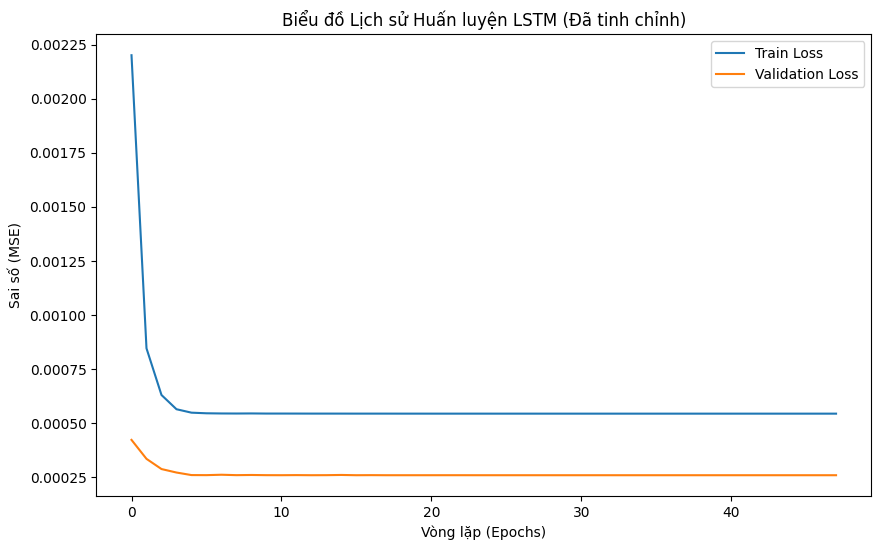

808/808 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step



--- KẾT QUẢ NGHIỆM THU CHO BTC/USDT ---
RMSE Baseline (Naive): 34.7801
RMSE LSTM (Returns):   34.7795
MAE LSTM:              22.7170
=> KẾT LUẬN: ĐẠT CHỈ TIÊU NGHIỆM THU.
Đã lưu thành công các tệp cấu hình: 'lstm_btc_model.h5' và 'scaler_btc.pkl'



In [27]:
history_btc = train_lstm_pipeline(df, "BTC/USDT")


BẮT ĐẦU PIPELINE HUẤN LUYỆN CHO: ETH/USDT


E0000 00:00:1779624513.262401    4506 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/user-k/Desktop/do an/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - loss: 0.0010 - val_loss: 2.5725e-04 - learning_rate: 0.0010
Epoch 2/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - loss: 4.5238e-04 - val_loss: 1.8548e-04 - learning_rate: 0.0010
Epoch 3/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - loss: 3.5163e-04 - val_loss: 1.5840e-04 - learning_rate: 0.0010
Epoch 4/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - loss: 3.2898e-04 - val_loss: 1.4592e-04 - learning_rate: 0.0010
Epoch 5/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - loss: 3.2593e-04 - val_loss: 1.4653e-04 - learning_rate: 0.0010
Epoch 6/100
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - loss: 3.2579e-04 - val_loss: 1.4917e-04 - learning_rate: 0.0010
Epoch 7/100
1294/1295 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.2137e-04
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - loss: 3.2555e-04 - val_loss: 1.4473e-04 - learning_rate: 0.0010
Epoc

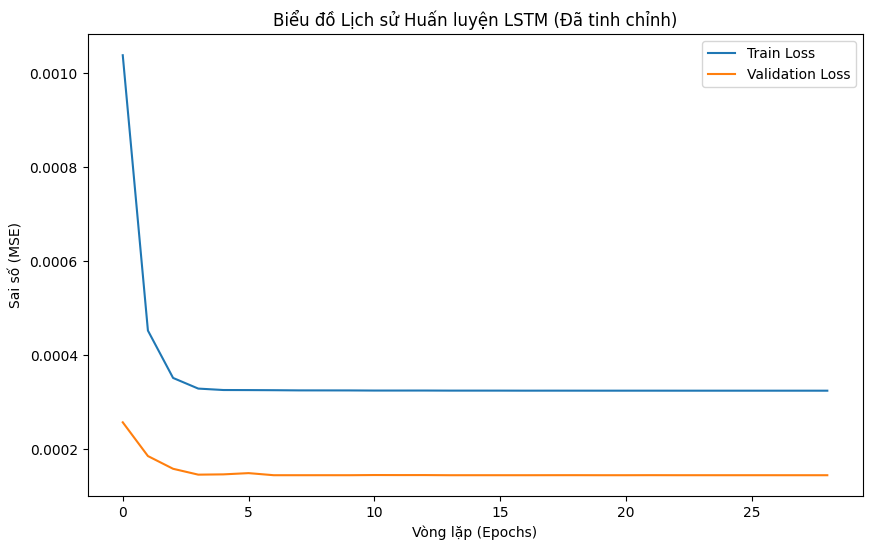

808/808 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step



--- KẾT QUẢ NGHIỆM THU CHO ETH/USDT ---
RMSE Baseline (Naive): 1.2921
RMSE LSTM (Returns):   1.2920
MAE LSTM:              0.8267
=> KẾT LUẬN: ĐẠT CHỈ TIÊU NGHIỆM THU.
Đã lưu thành công các tệp cấu hình: 'lstm_eth_model.h5' và 'scaler_eth.pkl'



In [5]:
history_eth = train_lstm_pipeline(df, "ETH/USDT")